In [2]:
# Importation des packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [5]:
# Importation des données
df = pd.read_excel('data/data.xlsx', header=1)

In [4]:
df.drop_duplicates(inplace=True)

In [6]:
df.duplicated().sum()

np.int64(278)

In [146]:
# Renommer les variables 
df = df.rename(columns={
    'Date operation': 'DATE_OPERATION', 
    'Montant': 'MONTANT', 
    'Duree': 'DUREE', 
    'PRIOD': 'PERIODE',
    'Taux %': 'TAUX_INT',
    'NBRE ECH': 'NB_ECH'})

In [147]:
df.head(3)

,DATE_OPERATION,LIBELLE,ACT,IND,INDLIB,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEX,VALEURGARANT,AGENCELIB,IMPAYE,NBIMP,MNTREMB,DATENAIS,ETATCIVIL,DEPNAISLIB,SECT_ACTIV
0,18-JUL-13,CREDITS D EQUIPEMENTS MT DC,DC,24.0,Autre Service,DDC,2500000.0,48,T,5.0,16,Male,NaN,NOUAKCHOTT 1 - SIEGE,0.0,0,180785.84,1971-01-20 00:00:00,Married,Adrar - Moughataa d'Atar,AUTRES SOCIETES
1,21-JUL-13,CREDITS D EQUIPEMENTS MT DC,DC,17.0,Commerce G�n�ral,DDC,2500000.0,48,T,5.0,16,Male,NaN,NOUAKCHOTT 1 - SIEGE,0.0,0,180785.84,25-FEB-59,Single,Toute la Mauritanie,AUTRES SOCIETES
2,21-JUL-13,CREDITS D EQUIPEMENTS MT DC,DC,NaN,NaN,DDC,2500000.0,48,T,5.0,16,Male,NaN,NOUAKCHOTT 1 - SIEGE,0.0,0,180785.84,30-DEC-77,Married,Assaba - Moughataa de Kiffa,AUTRES SOCIETES


In [148]:
# Convertir DATE_OPERATION en vraie date
df['DATE_OPERATION'] = pd.to_datetime(df['DATE_OPERATION'], errors='coerce')

# Convertir DUREE en numérique
df['DUREE'] = pd.to_numeric(df['DUREE'], errors='coerce')

# Date d'aujourd'hui
date_aujourdhui = pd.Timestamp.today().normalize()

# Créer la date de fin théorique du prêt : DATE_OPERATION + DUREE + 2 mois
df['DATE_FIN_PRET'] = df.apply(
    lambda row: row['DATE_OPERATION'] + pd.DateOffset(months=int(row['DUREE']) + 2)
    if pd.notna(row['DATE_OPERATION']) and pd.notna(row['DUREE'])
    else pd.NaT,
    axis=1
)

# Créer la variable statut
df['STATUT_DUREE'] = np.where(
    df['DATE_FIN_PRET'] <= date_aujourdhui,
    'Terminé',
    'En cours'
)

C:\Users\delli7\AppData\Local\Temp\ipykernel_23400\1652176308.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE_OPERATION'] = pd.to_datetime(df['DATE_OPERATION'], errors='coerce')


In [149]:
df['STATUT_DUREE'].value_counts(normalize=True)

STATUT_DUREE
Terminé     0.896249
En cours    0.103751
Name: proportion, dtype: float64

In [150]:
# Prendre seulement les prêts qui ont terminés
df = df[df['STATUT_DUREE'] == 'Terminé'].copy()

In [151]:
pd.set_option('display.max_columns', None)

In [152]:
df.shape

(26641, 23)

# Netoyage des données

### INDLIB

In [153]:
df['INDLIB'].isnull().sum()

np.int64(131)

In [154]:
# Supprimer les valeurs manquants (131 observations) du INDLIB
df = df.dropna(subset=['INDLIB'])

In [155]:
df['INDLIB'].unique()

<StringArray>
[                   'Autre Service',                 'Commerce G�n�ral',
  'Autre Industrie Non-Alimentaire', 'H�tel, Caf�, Retaurant, Spectacl',
                           'Divers',               'Industrie de P�che',
      'B�timent et Travaux Publics',              'Production Agricole',
  'Indus. Text Cuir et Habillement',      'Elevage, Production Animale',
            'Industrie Alimentaire', 'Indus. M�taux, Const M�ca & El�c',
  'Commerce Sp�cialis� Alimentaire',                   'Autre Commerce',
                       'Transports',  'Commerce V�hicules & Pi�ces D�t',
 'Commerce Mat.1�re, Const, Quinca', 'Industrie Materiaux Construction',
    'Industrie Bois et Ameublement', 'Prof. Immo, Const Immeuble Habit',
   'Prod, Extrac, Rafin Prod P�tro',  'Production et Distrib Eau/El�ct',
   'Extrac Minerai/Metal et Divers',  'Transit Manut, Auxiliare Transp',
 'Import & Distri Carburant & Comb']
Length: 25, dtype: str

In [156]:
corrections = {
    'H�tel, Caf�, Retaurant, Spectacl': 'Hôtel, Café, Restaurant, Spectacle',
    'Industrie de P�che': 'Industrie de Pêche',
    'Commerce G�n�ral': 'Commerce Général',
    'B�timent et Travaux Publics': 'Bâtiment et Travaux Publics',
    'Elevage, Production Animale': 'Élevage, Production Animale',
    'Indus. M�taux, Const M�ca & El�c': 'Industrie Métaux, Construction Mécanique & Électrique',
    'Commerce V�hicules & Pi�ces D�t': 'Commerce Véhicules & Pièces Détachées',
    'Indus. Text Cuir et Habillement': 'Industrie Textile, Cuir et Habillement',
    'Commerce Sp�cialis� Alimentaire': 'Commerce Spécialisé Alimentaire',
    'Commerce Mat.1�re, Const, Quinca': 'Commerce Matières Premières, Construction, Quincaillerie',
    'Industrie Materiaux Construction': 'Industrie Matériaux Construction',
    'Transit Manut, Auxiliare Transp': 'Transit, Manutention, Auxiliaire Transport',
    'Production et Distrib Eau/El�ct': 'Production et Distribution Eau/Électricité',
    'Prod, Extrac, Rafin Prod P�tro': 'Production, Extraction, Raffinage Produits Pétroliers'
}

df['INDLIB'] = df['INDLIB'].replace(corrections)

In [157]:
df.shape

(26510, 23)

### INDLIB & IND

In [158]:
mapping_indlib = {
    # Commerce
    'Commerce Général': 'Commerce',
    'Autre Commerce': 'Commerce',
    'Commerce Véhicules & Pièces Détachées': 'Commerce',
    'Commerce Spécialisé Alimentaire': 'Commerce',
    'Commerce Matières Premières, Construction, Quincaillerie': 'Commerce',

    # Services
    'Autre Service': 'Services',
    'Hôtel, Café, Restaurant, Spectacle': 'Services',
    'Transit, Manutention, Auxiliaire Transport': 'Services',

    # Industrie
    'Industrie de Pêche': 'Industrie',
    'Industrie Alimentaire': 'Industrie',
    'Industrie Bois et Ameublement': 'Industrie',
    'Industrie Matériaux Construction': 'Industrie',
    'Industrie Métaux, Construction Mécanique & Électrique': 'Industrie',
    'Industrie Textile, Cuir et Habillement': 'Industrie',
    'Autre Industrie Non-Alimentaire': 'Industrie',

    # Agriculture / Élevage
    'Production Agricole': 'Agriculture/Élevage',
    'Élevage, Production Animale': 'Agriculture/Élevage',

    # BTP / Construction
    'Bâtiment et Travaux Publics': 'BTP/Construction',
    'Prof. Immo, Const Immeuble Habit': 'BTP/Construction',

    # Transport
    'Transports': 'Transport',

    # Autres
    'Production et Distribution Eau/Électricité': 'Autres',
    'Production, Extraction, Raffinage Produits Pétroliers': 'Autres',
    'Extrac Minerai/Metal et Divers': 'Autres',
    'Import & Distri Carburant & Comb': 'Autres',
    'Divers': 'Autres'
}

# Supprimer l'ancienne variable si elle existe déjà
if 'INDLIB_GROUPE' in df.columns:
    df = df.drop(columns=['INDLIB_GROUPE'])

# Trouver la position de INDLIB
position_indlib = df.columns.get_loc('INDLIB')

# Créer INDLIB_GROUPE directement après INDLIB
df.insert(
    loc=position_indlib + 1,
    column='INDLIB_GROUPE',
    value=df['INDLIB'].map(mapping_indlib)
)

# Vérifier les modalités non catégorisées
df[df['INDLIB_GROUPE'].isna()]['INDLIB'].unique()

<StringArray>
[]
Length: 0, dtype: str

In [159]:
df['INDLIB_GROUPE'].value_counts()

INDLIB_GROUPE
Agriculture/Élevage    12688
Commerce                8302
Services                2125
Autres                  1977
Industrie                747
BTP/Construction         513
Transport                158
Name: count, dtype: int64

### PORTEF

La variable PORTEF désigne le portefeuille ou programme de financement auquel appartient le crédit. Certaines modalités correspondent à des programmes identifiés dans le rapport de la CDD, notamment CAM, FSE, ProPEP et Mon Projet Mon Avenir. D’autres modalités comme DDC, DD et PP semblent renvoyer à des directions ou catégories internes de gestion.

In [160]:
df['PORTEF'].isna().sum()

np.int64(194)

In [161]:
df = df.dropna(subset=['PORTEF'])

In [162]:
df['PORTEF'].value_counts(normalize=True).mul(100).round(2)

PORTEF
PP           33.64
CAM          28.40
FSE          25.80
DDC           7.53
PROPEP        2.26
PROJ_M_AV     2.04
DD            0.34
Name: proportion, dtype: float64

### MONTANT

<Axes: >

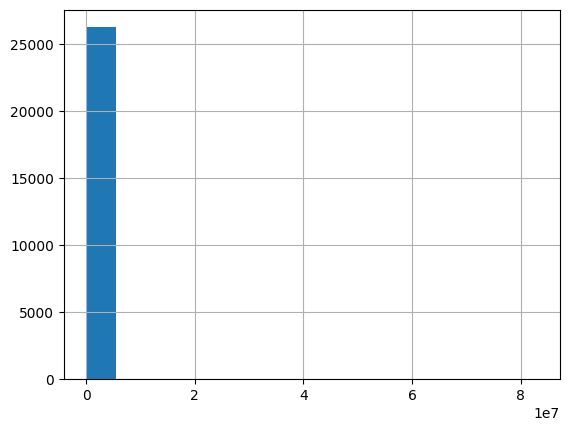

In [163]:
df['MONTANT'].hist(bins=15)

In [164]:
(df['MONTANT'] < 10000).sum()

np.int64(237)

In [165]:
df = df[df['MONTANT'] >= 10000].copy()

In [166]:
np.sort(df['DUREE'].unique())

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 70, 72, 74, 75,
       83, 84, 96])

### PERIODE

In [167]:
df['PERIODE'].value_counts()

PERIODE
M    18788
S     7119
T      160
B       10
A        2
Name: count, dtype: int64

In [168]:
# Supprimer le modalité 'B' et 'A' de la variable 'PERIOD'
df = df[(df['PERIODE'] != 'B') & (df['PERIODE'] != 'A')]

### SEX

In [169]:
# Supprimer les valeurs manquants
df = df.dropna(subset=['SEX'])

### VALEURGARANT

In [170]:
df['VALEURGARANT'].isnull().sum()

np.int64(25531)

In [171]:
# Convertir en numérique
df['MONTANT'] = pd.to_numeric(df['MONTANT'], errors='coerce')
df['VALEURGARANT'] = pd.to_numeric(df['VALEURGARANT'], errors='coerce')

# Créer la variable A_GARANTIE
df['A_GARANTIE'] = np.where(
    df['VALEURGARANT'].notna() & (df['VALEURGARANT'] > 0),
    'Oui',
    'Non'
)

# Insérer directement après VALEURGARANT
col = df.pop('A_GARANTIE')
pos = df.columns.get_loc('VALEURGARANT') + 1
df.insert(pos, 'A_GARANTIE', col)

# Vérification
df[['MONTANT', 'VALEURGARANT', 'A_GARANTIE']].head()

,MONTANT,VALEURGARANT,A_GARANTIE
0,2500000.0,NaN,Non
1,2500000.0,NaN,Non
6,2500000.0,NaN,Non
8,2500000.0,NaN,Non
10,2500000.0,NaN,Non


### AGENCELIB

In [172]:
# Mapping des agences vers les wilayas
mapping_agence_lieu = {
    'TRARZA  CAM': 'Trarza',
    'TRARZA': 'Trarza',
    'BOGHE CAM': 'Brakna',   # Boghé est dans la wilaya du Brakna

    'NOUAKCHOTT 1 - SIEGE': 'Nouakchott',

    'BRAKNA': 'Brakna',
    'GORGOL': 'Gorgol',
    'GORGOL CAM': 'Gorgol',

    'H.CHARGHI': 'Hodh Chargui',
    'H. GHARBI': 'Hodh Gharbi',

    'ASSABA': 'Assaba',
    'GUIDIMAGHA': 'Guidimagha',
    'ADRAR': 'Adrar',
    'DAKHLET NOUADIBOU': 'Dakhlet Nouadhibou',
    'TAGANT': 'Tagant',
    'INCHIRI': 'Inchiri',
    'T. ZEMOUR': 'Tiris Zemmour'
}

# Supprimer l'ancienne variable si elle existe déjà
if 'AGENCE_LIEU' in df.columns:
    df = df.drop(columns=['AGENCE_LIEU'])

# Trouver la position de AGENCELIB
position_agence = df.columns.get_loc('AGENCELIB')

# Créer AGENCE_LIEU directement après AGENCELIB
df.insert(
    loc=position_agence + 1,
    column='AGENCE_LIEU',
    value=df['AGENCELIB'].map(mapping_agence_lieu)
)

# Vérifier les agences non catégorisées
df[df['AGENCE_LIEU'].isna()]['AGENCELIB'].unique()

<StringArray>
[]
Length: 0, dtype: str

In [173]:
df['AGENCE_LIEU'].isna().sum()

np.int64(0)

### ETATCIVIL

In [174]:
df['ETATCIVIL'].value_counts()

ETATCIVIL
Married     19703
Single       5228
Divorced      945
Name: count, dtype: int64

### DATENAIS

In [175]:
df = df.dropna(subset=['DATENAIS'])

In [176]:
def clean_birth_date(x):
    if pd.isna(x):
        return pd.NaT

    # If already datetime
    if isinstance(x, (pd.Timestamp, datetime)):
        date = pd.to_datetime(x)

    # If Excel serial number
    elif isinstance(x, (int, float)):
        date = pd.to_datetime(x, origin='1899-12-30', unit='D')

    # If text like 25-MAY-72
    else:
        date = pd.to_datetime(x, format='%d-%b-%y', errors='coerce')

    # Correct future birth dates caused by 2-digit year problem
    if pd.notna(date) and date.year > datetime.today().year:
        date = date - pd.DateOffset(years=100)

    return date

df['DATENAIS'] = df['DATENAIS'].apply(clean_birth_date)

In [177]:
# Convert DATENAIS to datetime
df['DATENAIS'] = pd.to_datetime(df['DATENAIS'], errors='coerce')

# Calculate age
today = pd.Timestamp.today()

age = (
    today.year 
    - df['DATENAIS'].dt.year 
    - (
        (today.month < df['DATENAIS'].dt.month) |
        ((today.month == df['DATENAIS'].dt.month) & (today.day < df['DATENAIS'].dt.day))
    )
)

# Remove AGE if it already exists
df = df.drop(columns=['AGE'], errors='ignore')

# Insert AGE directly after DATENAIS
pos = df.columns.get_loc('DATENAIS') + 1
df.insert(pos, 'AGE', age)

In [178]:
# Supprimer les âges impossibles ou suspicious
df = df[(df['AGE'] >= 18) & (df['AGE'] <= 90)].copy()

In [179]:
df['AGE'].describe()

count    25852.000000
mean        51.512185
std         12.289427
min         22.000000
25%         42.000000
50%         51.000000
75%         60.000000
max         90.000000
Name: AGE, dtype: float64

### DEPNAISLIB

In [180]:
# Trouver la position de DEPNAISLIB
position_depnaislib = df.columns.get_loc('DEPNAISLIB')

# Créer WILAYA_NAISSANCE directement après DEPNAISLIB
df.insert(
    loc=position_depnaislib + 1,
    column='WILAYA_NAISSANCE',
    value=(
        df['DEPNAISLIB']
        .str.split(' - ')
        .str[0]
        .replace('Toute la Mauritanie', 'Inconnu')
        .fillna('Inconnu')
    )
)

# Vérifier la distribution en pourcentage
df['WILAYA_NAISSANCE'].value_counts(normalize=True).mul(100).round(2)

WILAYA_NAISSANCE
Inconnu             15.99
Trarza              14.63
Gorgol              12.30
Brakna              12.05
Assaba               7.29
Hodh Ech Chargui     7.25
Adrar                5.97
Nouakchott           5.48
Guidimakha           5.08
Tagant               4.83
Inchiri              3.17
Hodh el Gharbi       2.39
Nouadhibou           2.36
Tiris Zemmour        1.22
Name: proportion, dtype: float64

### TYPE_CLIENT

In [181]:
# Supprimer l'ancienne variable si elle existe déjà
df = df.drop(columns=['TYPE_CLIENT'], errors='ignore')

# Créer la variable TYPE_CLIENT à la fin du dataset
df['TYPE_CLIENT'] = np.where(
    df['VALEURGARANT'].isna() | (df['PORTEF'] == 'FSE'),
    'Public',
    'Privé'
)

df['TYPE_CLIENT'].value_counts()

TYPE_CLIENT
Public    25509
Privé       343
Name: count, dtype: int64

### DEFAUT

In [182]:
# Convertir NBIMP en numérique
df['NBIMP'] = pd.to_numeric(df['NBIMP'], errors='coerce')

# Supprimer l'ancienne variable si elle existe déjà
df = df.drop(columns=['DEFAUT'], errors='ignore')

# Créer la variable cible DEFAUT à la fin du dataset
df['DEFAUT'] = np.where(df['NBIMP'] > 0, 1, 0)

df['DEFAUT'].value_counts(normalize=True)

DEFAUT
1    0.516092
0    0.483908
Name: proportion, dtype: float64

In [183]:
df.head(2)

,DATE_OPERATION,LIBELLE,ACT,IND,INDLIB,INDLIB_GROUPE,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEX,VALEURGARANT,A_GARANTIE,AGENCELIB,AGENCE_LIEU,IMPAYE,NBIMP,MNTREMB,DATENAIS,AGE,ETATCIVIL,DEPNAISLIB,WILAYA_NAISSANCE,SECT_ACTIV,DATE_FIN_PRET,STATUT_DUREE,TYPE_CLIENT,DEFAUT
0,2013-07-18,CREDITS D EQUIPEMENTS MT DC,DC,24.0,Autre Service,Services,DDC,2500000.0,48,T,5.0,16,Male,NaN,Non,NOUAKCHOTT 1 - SIEGE,Nouakchott,0.0,0,180785.84,1971-01-20,55,Married,Adrar - Moughataa d'Atar,Adrar,AUTRES SOCIETES,2017-09-18,Terminé,Public,0
1,2013-07-21,CREDITS D EQUIPEMENTS MT DC,DC,17.0,Commerce Général,Commerce,DDC,2500000.0,48,T,5.0,16,Male,NaN,Non,NOUAKCHOTT 1 - SIEGE,Nouakchott,0.0,0,180785.84,1959-02-25,67,Single,Toute la Mauritanie,Inconnu,AUTRES SOCIETES,2017-09-21,Terminé,Public,0


In [184]:
# Supprimer des variables insignificatifs
df.drop(columns=['LIBELLE', 'ACT', 'IND', 'INDLIB', 'VALEURGARANT', 'AGENCELIB', 'DATENAIS', 'DEPNAISLIB', 'SECT_ACTIV', 'DATE_FIN_PRET', 'STATUT_DUREE'], inplace=True)

In [185]:
# Supprimer les doublons
df = df.drop_duplicates().reset_index(drop=True)

In [186]:
df.head(3)

,DATE_OPERATION,INDLIB_GROUPE,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEX,A_GARANTIE,AGENCE_LIEU,IMPAYE,NBIMP,MNTREMB,AGE,ETATCIVIL,WILAYA_NAISSANCE,TYPE_CLIENT,DEFAUT
0,2013-07-18,Services,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,55,Married,Adrar,Public,0
1,2013-07-21,Commerce,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,67,Single,Inconnu,Public,0
2,2013-07-21,Services,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,58,Married,Adrar,Public,0


In [187]:
# Exporter les données 
df.to_excel('data/working_dataset.xlsx', index=False)

In [188]:
df.duplicated().sum()

np.int64(0)

# Ingénerie des données